#### Multi-task architecture

One share model that does two things from the same street-view image:
1. Semantic segmentation, predict pixel-wise class like road, building, vegetation, car, sky, etc.
2. Scene classification, predict an visual drving-environment quality.

This is a natural next step because segmentation tells you where and classification tells you what kind of scene overall.

The model sees the image once. The shared encoder extracts visual features such as:
- road structure
- object distribution
- scence layout
- texture and spatial patterns

Then:
- the `segmentation head` uses those features to decide the class of each pixel
- the `classification head` compresses the overall scene into one vector and predicts a scene label

So the model learns both:
- local dense understanding
- global scene understanding

This is exactly why multi-task learning is appealing here.

A clear figure shows the idea:
```
Input image
    ↓
SegFormer encoder
    ↓
Shared feature maps
   ↙        ↘
Segmentation  Classification
head          head
```

Use:
- SegFormer backbone as shared encoder
- Segmentation head for pixel masks
- Classification head for image-level labels

In [1]:
# Environment setup
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

from transformers import SegformerModel
from tqdm.auto import tqdm

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [2]:
# reproducibility and device
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
# dataset root and label csv
DATA_ROOT = Path("data")
IMG_ROOT = DATA_ROOT / "leftImg8bit"
MASK_ROOT = DATA_ROOT / "gtFine"

LABEL_CSV = "cityscapes_quality_labels_train_thresholds.csv"

print("IMG_ROOT exists:", IMG_ROOT.exists())
print("MASK_ROOT exists:", MASK_ROOT.exists())
print("CSV exists:", Path(LABEL_CSV).exists())

IMG_ROOT exists: True
MASK_ROOT exists: True
CSV exists: True


In [4]:
# use the same segmentation label settings from stage1
IGNORE_INDEX = 255

CITYSCAPES_LABEL2TRAIN = {
    0: 255,
    1: 255,
    2: 255,
    3: 255,
    4: 255,
    5: 255,
    6: 255,
    7: 0,
    8: 1,
    9: 255,
    10: 255,
    11: 2,
    12: 3,
    13: 4,
    14: 255,
    15: 255,
    16: 255,
    17: 5,
    18: 255,
    19: 6,
    20: 7,
    21: 8,
    22: 9,
    23: 10,
    24: 11,
    25: 12,
    26: 13,
    27: 14,
    28: 15,
    29: 255,
    30: 255,
    31: 16,
    32: 17,
    33: 18,
    -1: 255
}

SEG_ID2LABEL = {
    0: "road",
    1: "sidewalk",
    2: "building",
    3: "wall",
    4: "fence",
    5: "pole",
    6: "traffic light",
    7: "traffic sign",
    8: "vegetation",
    9: "terrain",
    10: "sky",
    11: "person",
    12: "rider",
    13: "car",
    14: "truck",
    15: "bus",
    16: "train",
    17: "motorcycle",
    18: "bicycle"
}

SEG_LABEL2ID = {v: k for k, v in SEG_ID2LABEL.items()}
NUM_SEG_CLASSES = len(SEG_ID2LABEL)

SCENE_ID2LABEL = {
    0: "low",
    1: "moderate",
    2: "high"
}
SCENE_LABEL2ID = {v: k for k, v in SCENE_ID2LABEL.items()}
NUM_SCENE_CLASSES = len(SCENE_ID2LABEL)

print("NUM_SEG_CLASSES:", NUM_SEG_CLASSES)
print("NUM_SCENE_CLASSES:", NUM_SCENE_CLASSES)

NUM_SEG_CLASSES: 19
NUM_SCENE_CLASSES: 3


## Helper functions

In [5]:
# collect cityscapes pairs
def collect_cityscapes_pairs(split="train"):
    img_dir = IMG_ROOT / split
    mask_dir = MASK_ROOT / split

    pairs = []

    for city_folder in sorted(img_dir.iterdir()):
        if not city_folder.is_dir():
            continue

        city_name = city_folder.name
        mask_city_folder = mask_dir / city_name

        for img_path in sorted(city_folder.glob("*_leftImg8bit.png")):
            stem = img_path.name.replace("_leftImg8bit.png", "")
            mask_path = mask_city_folder / f"{stem}_gtFine_labelIds.png"

            if mask_path.exists():
                pairs.append((img_path, mask_path))

    return pairs


train_pairs = collect_cityscapes_pairs("train")
val_pairs = collect_cityscapes_pairs("val")

print("Train pairs:", len(train_pairs))
print("Val pairs:", len(val_pairs))

Train pairs: 2975
Val pairs: 500


In [6]:
# ENCODER segementation mask
def encode_segmap(mask_np):
    encoded = np.full(mask_np.shape, IGNORE_INDEX, dtype=np.uint8)
    for label_id, train_id in CITYSCAPES_LABEL2TRAIN.items():
        encoded[mask_np == label_id] = train_id
    return encoded

In [7]:
# Image ID helper
def get_image_id_from_img_path(img_path):
    return Path(img_path).name.replace("_leftImg8bit.png", "")

## Load quality CSV

In [8]:
# load quality label csv
quality_df = pd.read_csv(LABEL_CSV)
quality_df.head()

,image_id,split,gvi,ruci,quality_score,quality_class,quality_label
0,aachen_000000_000019,train,0.112554,0.055490,0.528532,2,high
1,aachen_000001_000019,train,0.110589,0.037512,0.536538,2,high
2,aachen_000002_000019,train,0.294998,0.132582,0.581208,2,high
3,aachen_000003_000019,train,0.000000,0.202013,0.398994,0,low
4,aachen_000004_000019,train,0.035710,0.074123,0.480794,1,moderate


In [9]:
print(quality_df["split"].value_counts())
print(quality_df["quality_label"].value_counts())
print(pd.crosstab(quality_df["split"], quality_df["quality_label"]))

split
train    2975
val       500
Name: count, dtype: int64
quality_label
high        1168
low         1162
moderate    1145
Name: count, dtype: int64
quality_label  high  low  moderate
split                             
train           992  992       991
val             176  170       154


In [10]:
# build dictionaries separately for train and val
train_cls_df = quality_df[quality_df["split"] == "train"].copy()
val_cls_df = quality_df[quality_df["split"] == "val"].copy()

train_cls_label_map = dict(zip(train_cls_df["image_id"], train_cls_df["quality_class"]))
val_cls_label_map = dict(zip(val_cls_df["image_id"], val_cls_df["quality_class"]))

print("Train classification labels:", len(train_cls_label_map))
print("Val classification labels:", len(val_cls_label_map))

Train classification labels: 2975
Val classification labels: 500


## Multi-task dataset

This dataset returns:
- image tensor
- segmentation mask
- scene quality label
- image ID

In [11]:
class CityscapesMultiTaskDataset(Dataset):
    def __init__(self, pairs, cls_label_map, image_size=(512, 1024), augment=False):
        self.image_size = image_size
        self.augment = augment
        self.cls_label_map = cls_label_map

        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

        filtered_pairs = []
        for img_path, mask_path in pairs:
            image_id = get_image_id_from_img_path(img_path)
            if image_id in self.cls_label_map:
                filtered_pairs.append((img_path, mask_path))

        self.pairs = filtered_pairs
        print(f"Dataset initialized with {len(self.pairs)} samples")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image_id = get_image_id_from_img_path(img_path)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        image = TF.resize(image, self.image_size, interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, self.image_size, interpolation=InterpolationMode.NEAREST)

        if self.augment and random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=self.mean, std=self.std)

        mask = np.array(mask, dtype=np.int64)
        mask = encode_segmap(mask)
        mask = torch.from_numpy(mask).long()

        scene_label = torch.tensor(self.cls_label_map[image_id], dtype=torch.long)

        return {
            "pixel_values": image,
            "labels": mask,
            "scene_label": scene_label,
            "image_id": image_id
        }

## Build datasets and dataloaders

For the first run, keep it modest.

In [12]:
train_mt_dataset = CityscapesMultiTaskDataset(
    train_pairs,
    cls_label_map=train_cls_label_map,
    image_size=(512, 1024),
    augment=True
)

val_mt_dataset = CityscapesMultiTaskDataset(
    val_pairs,
    cls_label_map=val_cls_label_map,
    image_size=(512, 1024),
    augment=False
)

train_mt_loader = DataLoader(
    train_mt_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_mt_loader = DataLoader(
    val_mt_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Dataset initialized with 2975 samples
Dataset initialized with 500 samples


## Quick sanity check

In [13]:
batch = next(iter(train_mt_loader))

print(batch["pixel_values"].shape)
print(batch["labels"].shape)
print(batch["scene_label"].shape)
print("Unique segmentation labels:", torch.unique(batch["labels"]))
print("Unique scene labels in batch:", torch.unique(batch["scene_label"]))
print("First few image IDs:", batch["image_id"][:3])

torch.Size([2, 3, 512, 1024])
torch.Size([2, 512, 1024])
torch.Size([2])
Unique segmentation labels: tensor([  0,   1,   2,   4,   5,   6,   7,   8,  10,  11,  13,  18, 255])
Unique scene labels in batch: tensor([0, 1])
First few image IDs: ['strasbourg_000000_032346', 'bremen_000064_000019']


- The unique segmentation labels including `255` are also normal. `255` is the ignore label
- The fact that the batch only contains scene label `0` and `1` in that one sample batch is not a problem. That just means that specific batch did not happen to include class `2`.

## Multi-task model

This is the shared encoder with two heads

In [14]:
class SegFormerMultiTask(nn.Module):
    def __init__(self, num_seg_classes, num_scene_classes, backbone_name="nvidia/mit-b0"):
        super().__init__()

        self.encoder = SegformerModel.from_pretrained(backbone_name)

        hidden_sizes = self.encoder.config.hidden_sizes
        encoder_out_channels = hidden_sizes[-1]

        self.seg_head = nn.Conv2d(
            in_channels=encoder_out_channels,
            out_channels=num_seg_classes,
            kernel_size=1
        )

        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(encoder_out_channels, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_scene_classes)
        )

    def forward(self, pixel_values):
        outputs = self.encoder(pixel_values=pixel_values, output_hidden_states=True)

        feat = outputs.last_hidden_state  # (B, C, H', W')

        seg_logits = self.seg_head(feat)
        cls_logits = self.cls_head(feat)

        return {
            "seg_logits": seg_logits,
            "cls_logits": cls_logits
        }

## Build model, optimizer, losses

In [15]:
model_mt = SegFormerMultiTask(
    num_seg_classes=NUM_SEG_CLASSES,
    num_scene_classes=NUM_SCENE_CLASSES,
    backbone_name="nvidia/mit-b0"
).to(device)

optimizer = torch.optim.AdamW(model_mt.parameters(), lr=6e-5, weight_decay=1e-4)

seg_criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
cls_criterion = nn.CrossEntropyLoss()

lambda_seg = 1.0
lambda_cls = 0.5

print("Model ready.")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready.


# Segmentation metrics

Here reuse confusion-matrix logic from stage1

In [16]:
def compute_confusion_matrix(preds, labels, num_classes, ignore_index=255):
    preds = preds.detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()

    mask = labels != ignore_index
    preds = preds[mask]
    labels = labels[mask]

    conf_mat = np.bincount(
        num_classes * labels + preds,
        minlength=num_classes ** 2
    ).reshape(num_classes, num_classes)

    return conf_mat


def compute_seg_metrics_from_confmat(conf_mat):
    acc = np.diag(conf_mat).sum() / (conf_mat.sum() + 1e-10)

    ious = []
    for i in range(conf_mat.shape[0]):
        tp = conf_mat[i, i]
        fp = conf_mat[:, i].sum() - tp
        fn = conf_mat[i, :].sum() - tp
        denom = tp + fp + fn
        iou = tp / denom if denom > 0 else np.nan
        ious.append(iou)

    miou = np.nanmean(ious)
    return acc, ious, miou

## Training loop

In [17]:
def train_one_epoch_multitask(
    model,
    dataloader,
    optimizer,
    seg_criterion,
    cls_criterion,
    lambda_seg,
    lambda_cls,
    device
):
    model.train()

    total_loss = 0.0
    total_seg_loss = 0.0
    total_cls_loss = 0.0

    pbar = tqdm(dataloader, desc="Training", leave=False)

    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        scene_label = batch["scene_label"].to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values)
        seg_logits = outputs["seg_logits"]
        cls_logits = outputs["cls_logits"]

        seg_logits = F.interpolate(
            seg_logits,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        seg_loss = seg_criterion(seg_logits, labels)
        cls_loss = cls_criterion(cls_logits, scene_label)

        loss = lambda_seg * seg_loss + lambda_cls * cls_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_seg_loss += seg_loss.item()
        total_cls_loss += cls_loss.item()

        pbar.set_postfix(
            total=f"{loss.item():.4f}",
            seg=f"{seg_loss.item():.4f}",
            cls=f"{cls_loss.item():.4f}"
        )

    n = len(dataloader)
    return {
        "total_loss": total_loss / n,
        "seg_loss": total_seg_loss / n,
        "cls_loss": total_cls_loss / n
    }

## Validation loop

This reports both segmentation and classification metrics.

In [18]:
@torch.no_grad()
def evaluate_multitask(
    model,
    dataloader,
    seg_criterion,
    cls_criterion,
    lambda_seg,
    lambda_cls,
    device,
    num_seg_classes
):
    model.eval()

    total_loss = 0.0
    total_seg_loss = 0.0
    total_cls_loss = 0.0

    seg_conf_mat = np.zeros((num_seg_classes, num_seg_classes), dtype=np.int64)

    all_scene_true = []
    all_scene_pred = []

    pbar = tqdm(dataloader, desc="Validation", leave=False)

    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        scene_label = batch["scene_label"].to(device)

        outputs = model(pixel_values)
        seg_logits = outputs["seg_logits"]
        cls_logits = outputs["cls_logits"]

        seg_logits = F.interpolate(
            seg_logits,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        seg_loss = seg_criterion(seg_logits, labels)
        cls_loss = cls_criterion(cls_logits, scene_label)
        loss = lambda_seg * seg_loss + lambda_cls * cls_loss

        total_loss += loss.item()
        total_seg_loss += seg_loss.item()
        total_cls_loss += cls_loss.item()

        seg_preds = torch.argmax(seg_logits, dim=1)
        seg_conf_mat += compute_confusion_matrix(
            seg_preds, labels, num_seg_classes, IGNORE_INDEX
        )

        cls_preds = torch.argmax(cls_logits, dim=1)

        all_scene_true.extend(scene_label.cpu().numpy().tolist())
        all_scene_pred.extend(cls_preds.cpu().numpy().tolist())

    seg_acc, seg_ious, seg_miou = compute_seg_metrics_from_confmat(seg_conf_mat)

    cls_acc = accuracy_score(all_scene_true, all_scene_pred)
    cls_macro_f1 = f1_score(all_scene_true, all_scene_pred, average="macro")
    cls_conf_mat = confusion_matrix(all_scene_true, all_scene_pred, labels=[0, 1, 2])

    n = len(dataloader)
    return {
        "total_loss": total_loss / n,
        "seg_loss": total_seg_loss / n,
        "cls_loss": total_cls_loss / n,
        "seg_acc": seg_acc,
        "seg_ious": seg_ious,
        "seg_miou": seg_miou,
        "cls_acc": cls_acc,
        "cls_macro_f1": cls_macro_f1,
        "cls_conf_mat": cls_conf_mat,
        "scene_true": all_scene_true,
        "scene_pred": all_scene_pred
    }

ERROR! Session/line number was not unique in database. History logging moved to new session 15


## Training run

In [19]:
num_epochs = 10
best_score = -1
save_path_mt = "segformer_multitask_quality_best.pth"

history = {
    "train_total_loss": [],
    "train_seg_loss": [],
    "train_cls_loss": [],
    "val_total_loss": [],
    "val_seg_loss": [],
    "val_cls_loss": [],
    "val_seg_miou": [],
    "val_seg_acc": [],
    "val_cls_acc": [],
    "val_cls_macro_f1": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_metrics = train_one_epoch_multitask(
        model_mt,
        train_mt_loader,
        optimizer,
        seg_criterion,
        cls_criterion,
        lambda_seg,
        lambda_cls,
        device
    )

    val_metrics = evaluate_multitask(
        model_mt,
        val_mt_loader,
        seg_criterion,
        cls_criterion,
        lambda_seg,
        lambda_cls,
        device,
        NUM_SEG_CLASSES
    )

    history["train_total_loss"].append(train_metrics["total_loss"])
    history["train_seg_loss"].append(train_metrics["seg_loss"])
    history["train_cls_loss"].append(train_metrics["cls_loss"])

    history["val_total_loss"].append(val_metrics["total_loss"])
    history["val_seg_loss"].append(val_metrics["seg_loss"])
    history["val_cls_loss"].append(val_metrics["cls_loss"])
    history["val_seg_miou"].append(val_metrics["seg_miou"])
    history["val_seg_acc"].append(val_metrics["seg_acc"])
    history["val_cls_acc"].append(val_metrics["cls_acc"])
    history["val_cls_macro_f1"].append(val_metrics["cls_macro_f1"])

    print(f"Train Total Loss: {train_metrics['total_loss']:.4f}")
    print(f"Train Seg Loss:   {train_metrics['seg_loss']:.4f}")
    print(f"Train Cls Loss:   {train_metrics['cls_loss']:.4f}")

    print(f"Val Total Loss:   {val_metrics['total_loss']:.4f}")
    print(f"Val Seg Loss:     {val_metrics['seg_loss']:.4f}")
    print(f"Val Cls Loss:     {val_metrics['cls_loss']:.4f}")
    print(f"Val Seg Acc:      {val_metrics['seg_acc']:.4f}")
    print(f"Val Seg mIoU:     {val_metrics['seg_miou']:.4f}")
    print(f"Val Cls Acc:      {val_metrics['cls_acc']:.4f}")
    print(f"Val Cls Macro F1: {val_metrics['cls_macro_f1']:.4f}")

    score = val_metrics["seg_miou"] + 0.2 * val_metrics["cls_macro_f1"]

    if score > best_score:
        best_score = score
        torch.save(model_mt.state_dict(), save_path_mt)
        print(f"Best multitask model saved to: {save_path_mt}")


Epoch 1/10


Training:   0%|          | 0/1488 [00:00<?, ?it/s]

Validation:   0%|          | 0/250 [00:00<?, ?it/s]

Train Total Loss: 0.7472
Train Seg Loss:   0.4809
Train Cls Loss:   0.5324
Val Total Loss:   0.6298
Val Seg Loss:     0.3767
Val Cls Loss:     0.5061
Val Seg Acc:      0.8817
Val Seg mIoU:     0.3846
Val Cls Acc:      0.7960
Val Cls Macro F1: 0.7893
Best multitask model saved to: segformer_multitask_quality_best_ep10.pth

Epoch 2/10


Training:   0%|          | 0/1488 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/250 [00:00<?, ?it/s]

Train Total Loss: 0.3380
Train Seg Loss:   0.2667
Train Cls Loss:   0.1425
Val Total Loss:   0.5000
Val Seg Loss:     0.3014
Val Cls Loss:     0.3971
Val Seg Acc:      0.9018
Val Seg mIoU:     0.4923
Val Cls Acc:      0.8780
Val Cls Macro F1: 0.8790

Epoch 10/10


Training:   0%|          | 0/1488 [00:00<?, ?it/s]

Validation:   0%|          | 0/250 [00:00<?, ?it/s]

Train Total Loss: 0.3359
Train Seg Loss:   0.2639
Train Cls Loss:   0.1438
Val Total Loss:   0.5140
Val Seg Loss:     0.2963
Val Cls Loss:     0.4354
Val Seg Acc:      0.9027
Val Seg mIoU:     0.5006
Val Cls Acc:      0.8640
Val Cls Macro F1: 0.8605


## Plot training history

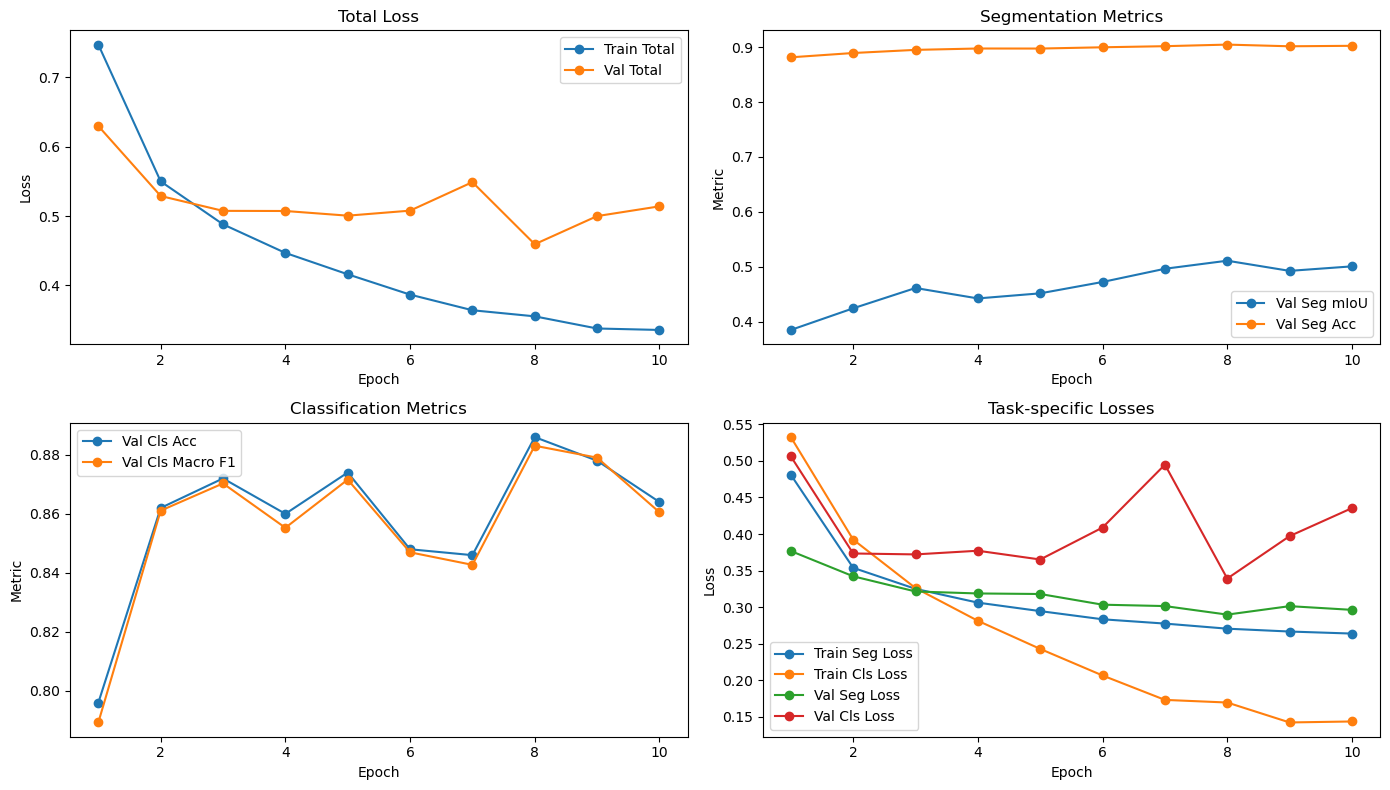

In [20]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.plot(epochs, history["train_total_loss"], marker="o", label="Train Total")
plt.plot(epochs, history["val_total_loss"], marker="o", label="Val Total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Total Loss")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(epochs, history["val_seg_miou"], marker="o", label="Val Seg mIoU")
plt.plot(epochs, history["val_seg_acc"], marker="o", label="Val Seg Acc")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Segmentation Metrics")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(epochs, history["val_cls_acc"], marker="o", label="Val Cls Acc")
plt.plot(epochs, history["val_cls_macro_f1"], marker="o", label="Val Cls Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Classification Metrics")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(epochs, history["train_seg_loss"], marker="o", label="Train Seg Loss")
plt.plot(epochs, history["train_cls_loss"], marker="o", label="Train Cls Loss")
plt.plot(epochs, history["val_seg_loss"], marker="o", label="Val Seg Loss")
plt.plot(epochs, history["val_cls_loss"], marker="o", label="Val Cls Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task-specific Losses")
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
plt.savefig("outputs/training_history_epoch10_multitaskmodel.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Load best model

In [21]:
best_model_mt = SegFormerMultiTask(
    num_seg_classes=NUM_SEG_CLASSES,
    num_scene_classes=NUM_SCENE_CLASSES,
    backbone_name="nvidia/mit-b0"
).to(device)

best_model_mt.load_state_dict(torch.load(save_path_mt, map_location=device))
best_model_mt.eval()

print("Best multitask model loaded.")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Best multitask model loaded.


## Final evaluation summary

In [22]:
final_metrics = evaluate_multitask(
    best_model_mt,
    val_mt_loader,
    seg_criterion,
    cls_criterion,
    lambda_seg,
    lambda_cls,
    device,
    NUM_SEG_CLASSES
)

print("Final Validation Results")
print(f"Seg Acc:      {final_metrics['seg_acc']:.4f}")
print(f"Seg mIoU:     {final_metrics['seg_miou']:.4f}")
print(f"Cls Acc:      {final_metrics['cls_acc']:.4f}")
print(f"Cls Macro F1: {final_metrics['cls_macro_f1']:.4f}")

Validation:   0%|          | 0/250 [00:00<?, ?it/s]

Final Validation Results
Seg Acc:      0.9073
Seg mIoU:     0.5288
Cls Acc:      0.8100
Cls Macro F1: 0.8031


### Analysis
#### Segmentation side

Compared wit stage1 baseline:
- stage1 final mIoU after 5 epochs was 0.5852
- stage2 final mIoU is 0.5288
So at the current setting, the multi-task model appears to have reduced segmentation performance somewhat.

This is not a failure. It is actually very common in multi-task learning:

- the shared encoder now has to serve two objectives
- the classification branch competes for representation capacity
- the segmentation decoder in stage2 model is simpler than the original SegFormer segmentation head

In stage1, I used `SegformerForSemanticSegmentation`

In stage2, I used `SegformerModel` + a very simple `1x1 conv` segmentation head

So part of the performance drop may come from architecture simplication, not only from multi-task learning itself.

That means the stage2 is still valid, but the comparison must be interpreted carefully.

#### Classification side

The classification results is actually quite strong:
- Accuracy = 0.8100
- Macro F1 = 0.8031

For a 3-class problem with derived labels:
- low
- moderate
- high

It suggests that the shared encoder is learning image-level semantic composition patterns related to:

- greenery
- road occupancy
- overall visual quality structure

## Classification confusion matrix

In [23]:
cls_cm = final_metrics["cls_conf_mat"]

print("Classification Confusion Matrix")
print(cls_cm)

Classification Confusion Matrix
[[106  57   7]
 [  0 125  29]
 [  0   2 174]]


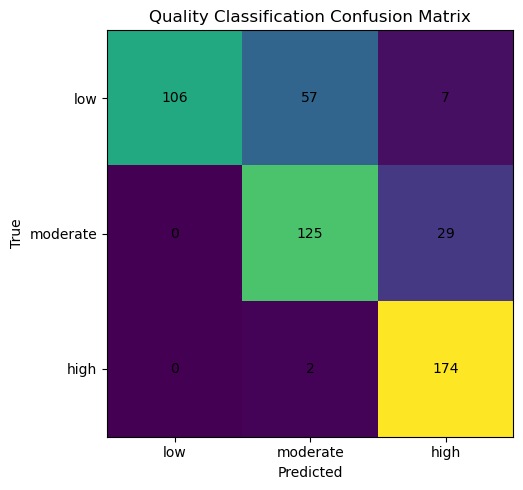

In [24]:
# pretty print it
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cls_cm)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels([SCENE_ID2LABEL[i] for i in range(NUM_SCENE_CLASSES)])
ax.set_yticklabels([SCENE_ID2LABEL[i] for i in range(NUM_SCENE_CLASSES)])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Quality Classification Confusion Matrix")

for i in range(cls_cm.shape[0]):
    for j in range(cls_cm.shape[1]):
        ax.text(j, i, cls_cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## Classification report

This gives you:

- precision
- recall
- F1-score per class

Very useful for your report.

In [25]:
print(
    classification_report(
        final_metrics["scene_true"],
        final_metrics["scene_pred"],
        target_names=[SCENE_ID2LABEL[i] for i in range(NUM_SCENE_CLASSES)],
        digits=4
    )
)

              precision    recall  f1-score   support

         low     1.0000    0.6235    0.7681       170
    moderate     0.6793    0.8117    0.7396       154
        high     0.8286    0.9886    0.9016       176

    accuracy                         0.8100       500
   macro avg     0.8360    0.8080    0.8031       500
weighted avg     0.8409    0.8100    0.8063       500



## Per-class IoU for segmentation

In [26]:
for class_id, class_name in SEG_ID2LABEL.items():
    print(f"{class_id:2d} | {class_name:15s} | IoU: {final_metrics['seg_ious'][class_id]:.4f}")

 0 | road            | IoU: 0.9528
 1 | sidewalk        | IoU: 0.6829
 2 | building        | IoU: 0.8334
 3 | wall            | IoU: 0.3635
 4 | fence           | IoU: 0.3685
 5 | pole            | IoU: 0.1608
 6 | traffic light   | IoU: 0.2537
 7 | traffic sign    | IoU: 0.4173
 8 | vegetation      | IoU: 0.8422
 9 | terrain         | IoU: 0.5106
10 | sky             | IoU: 0.8561
11 | person          | IoU: 0.5206
12 | rider           | IoU: 0.2319
13 | car             | IoU: 0.8339
14 | truck           | IoU: 0.4159
15 | bus             | IoU: 0.5777
16 | train           | IoU: 0.4709
17 | motorcycle      | IoU: 0.2217
18 | bicycle         | IoU: 0.5336


## Visualization helpers

**Segmentation color palette**

In [27]:
CITYSCAPES_COLORS = np.array([
    [128, 64, 128],
    [244, 35, 232],
    [70, 70, 70],
    [102, 102, 156],
    [190, 153, 153],
    [153, 153, 153],
    [250, 170, 30],
    [220, 220, 0],
    [107, 142, 35],
    [152, 251, 152],
    [70, 130, 180],
    [220, 20, 60],
    [255, 0, 0],
    [0, 0, 142],
    [0, 0, 70],
    [0, 60, 100],
    [0, 80, 100],
    [0, 0, 230],
    [119, 11, 32],
], dtype=np.uint8)

def decode_segmap(mask):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id in range(NUM_SEG_CLASSES):
        color_mask[mask == class_id] = CITYSCAPES_COLORS[class_id]

    return color_mask

In [28]:
# overlay helper
def overlay_mask_on_image(image, color_mask, alpha=0.5):
    overlay = (1 - alpha) * image + alpha * (color_mask / 255.0)
    return np.clip(overlay, 0, 1)

## Predict one validation sample

In [29]:
@torch.no_grad()
def predict_multitask_sample(model, dataset, idx, device):
    sample = dataset[idx]
    pixel_values = sample["pixel_values"].unsqueeze(0).to(device)
    gt_mask = sample["labels"].numpy()
    gt_scene = sample["scene_label"].item()
    image_id = sample["image_id"]

    outputs = model(pixel_values)
    seg_logits = outputs["seg_logits"]
    cls_logits = outputs["cls_logits"]

    seg_logits = F.interpolate(
        seg_logits,
        size=gt_mask.shape,
        mode="bilinear",
        align_corners=False
    )

    pred_mask = torch.argmax(seg_logits, dim=1).squeeze(0).cpu().numpy()
    pred_scene = torch.argmax(cls_logits, dim=1).item()

    img = sample["pixel_values"].clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    return {
        "image_id": image_id,
        "image": img,
        "gt_mask": gt_mask,
        "pred_mask": pred_mask,
        "gt_scene": gt_scene,
        "pred_scene": pred_scene
    }

## Visualize a sample

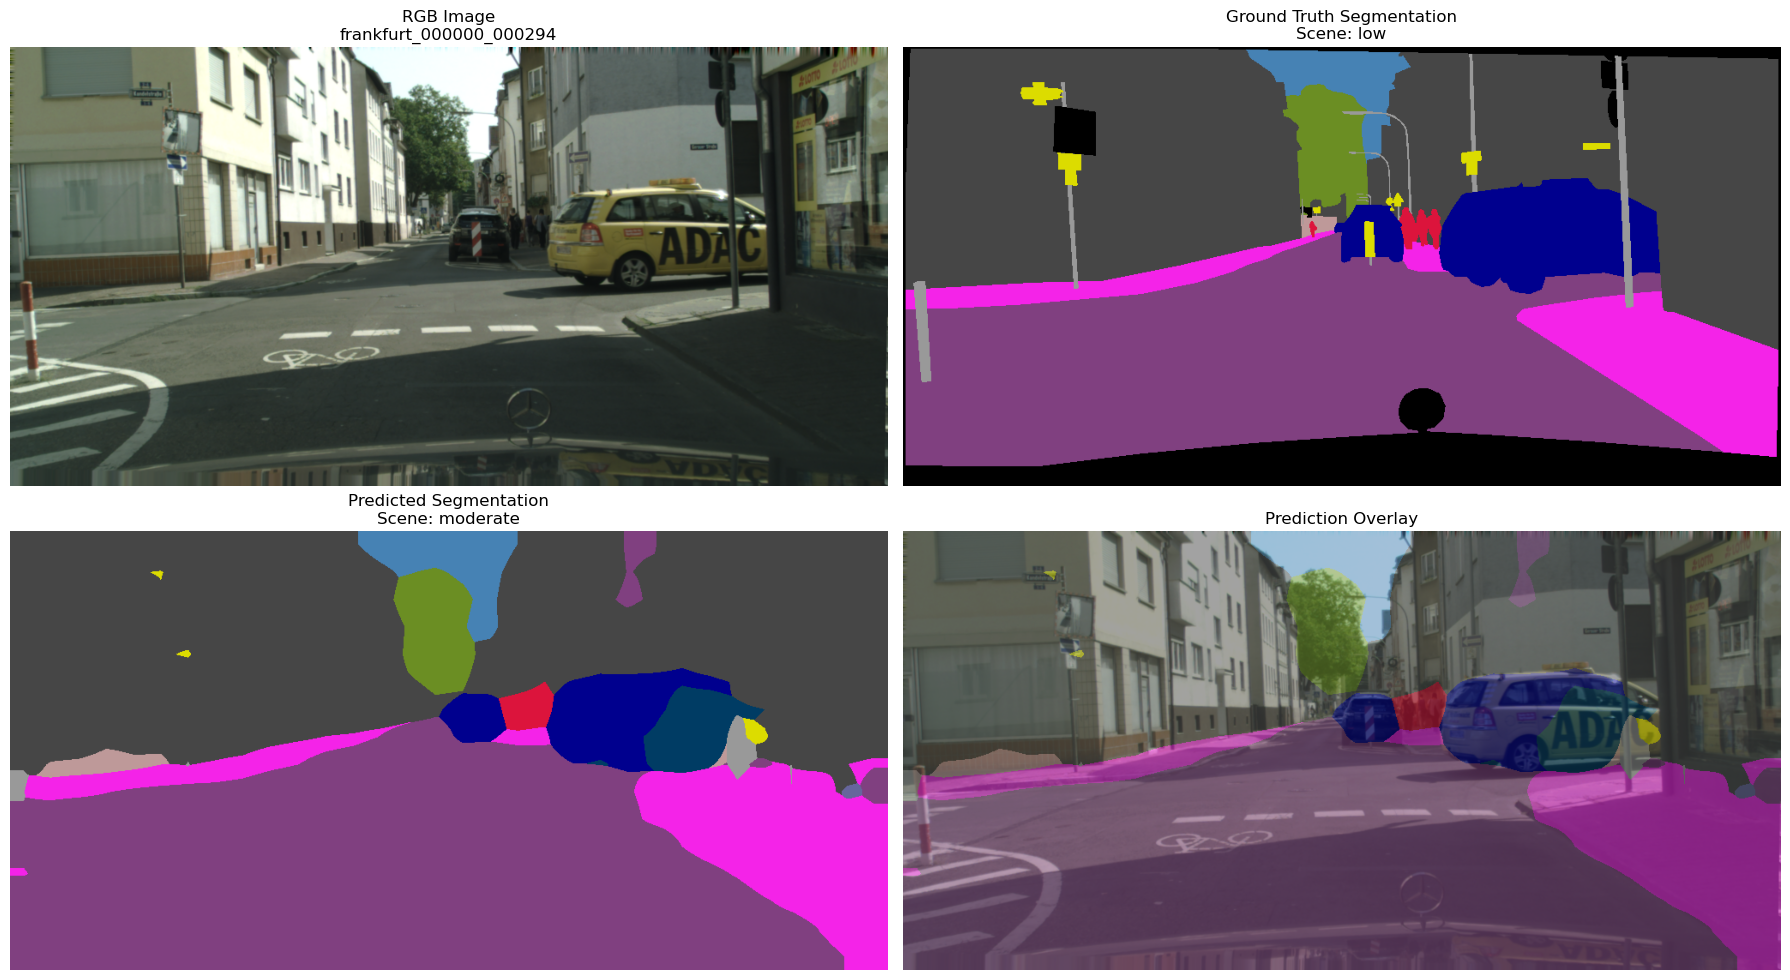

In [30]:
sample_pred = predict_multitask_sample(best_model_mt, val_mt_dataset, idx=0, device=device)

img = sample_pred["image"]
gt_mask = sample_pred["gt_mask"]
pred_mask = sample_pred["pred_mask"]

gt_color = decode_segmap(gt_mask)
pred_color = decode_segmap(pred_mask)

gt_overlay = overlay_mask_on_image(img, gt_color, alpha=0.5)
pred_overlay = overlay_mask_on_image(img, pred_color, alpha=0.5)

plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title(f"RGB Image\n{sample_pred['image_id']}")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gt_color)
plt.title(f"Ground Truth Segmentation\nScene: {SCENE_ID2LABEL[sample_pred['gt_scene']]}")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(pred_color)
plt.title(f"Predicted Segmentation\nScene: {SCENE_ID2LABEL[sample_pred['pred_scene']]}")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(pred_overlay)
plt.title("Prediction Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

## Essential interpretation

```
A multi-task learning framework was developed using a shared SegFormer encoder with parallel task head, The first head performed semantic segmentation of urban street-view imagery, while the second head predicted image-level driving-environment quality classes derived from semantic composition indicators. The classification labels represented low-, moderate-, and high-quality visual driving environments based on the combination of Greenery View Index and Road User Complexity Index.
```